---
title: Annual max summer heat index
author: Harsha R. Hampapura
date: "13-04-2026"
---

## Annual Maximum JJA Heat Index at Boulder, CO and Chicago, IL (1990–2025)
### ERA5 and JRA-3Q Reanalyses from NCAR GDEX

### Scientific motivation

This notebook computes the annual maximum June–July–August (JJA) heat index
at two mid-latitude United States cities — Boulder, Colorado (semi-arid,
elevation 1655 m) and Chicago, Illinois (humid continental, Lake Michigan
influence) — using two independent global reanalyses spanning 1990–2025.

The analysis follows the methodology of
[Romps (2024)](https://davidromps.com/papers/pubs-2023-texas.html), who
demonstrated using ERA5 that the annual maximum summer heat index in Texas
has increased at a rate several times larger than the contemporaneous increase
in dry-bulb temperature. The physical basis for this amplification lies in the
nonlinearity of the heat index with respect to temperature and humidity: at
near-saturated conditions, the Clausius–Clapeyron relation implies that a given
increment of warming produces a disproportionately large increase in
physiological heat stress. Chicago, situated in a persistently humid air mass,
is expected to exhibit stronger amplification than semi-arid Boulder, where the
heat index remains close to the dry-bulb temperature throughout the summer.

### Datasets

| Product | GDEX identifier | Temporal resolution | Quantity archived | Access format |
|---|---|---|---|---|
| ERA5 surface analysis | d633000 | Hourly instantaneous | `VAR_2T`, `VAR_2D` | Native Zarr |
| JRA-3Q surface analysis (`anl_surf125`) | d640000 | 6-hourly instantaneous | `TMP_GDS0_HTGL`, `RH_GDS0_HTGL` | kerchunk reference |


Because ERA5 provides 24 candidate values per day versus 4 for JRA-3Q, computing
the JJA season maximum from the full hourly ERA5 stream would systematically
inflate ERA5 relative to JRA-3Q through a sample-size effect alone. To remove
this artifact, ERA5 is subsampled to one randomly selected observation per 6-hour
window prior to computing the annual maximum, matching the JRA-3Q cadence. A
random draw, rather than a fixed synoptic hour, is used to avoid introducing a
systematic diurnal-phase bias into the sampled ERA5 distribution.

:::{important} Important Info for the Data
ERA5 data from ECMFW is available on NCAR GDEX at https://gdex.ucar.edu/datasets/d633000/#
:::

### Heat index formulation

The heat index is computed using the `heatindex` Python package of Lu & Romps
(2025), which implements the extended formulation of Lu & Romps (2022) in python.
The function takes air temperature in Kelvin and relative humidity on the
interval $[0,\,1]$ and returns the heat index in Kelvin:

```python
hi.heatindex(T_K, rh)  →  HI_K
```

ERA5 does not archive near-surface relative humidity directly. It is derived from
the 2-m temperature (`VAR_2T`) and 2-m dew-point temperature (`VAR_2D`) via the
August–Roche–Magnus approximation, consistent with the ECMWF IFS documentation.
JRA-3Q provides relative humidity in percent as `RH_GDS0_HTGL` in the surface
analysis product.

## Required Packages
Please make sure to install the packages before moving forward
- intake
- intake-esm >= 2025.12.12
- xarray
- dask
- zarr
- kerchunk
- numpy
- pandas
- matplotlib
- heatindex >= 0.0.2

In [1]:
!pip install heatindex

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr
import intake
import intake_esm
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask 
from dask_jobqueue import PBSCluster
from dask.distributed import Client

## Step 1 - Locate the Dataset
On the NCAR GDEX portal, go to the `Data Access` tab for the ERA5/ JRA-3Q dataset to find the intake-ESM catalogs needed to access data. In this notebook we will use GDEX POSIX catalog.

In [3]:
# Please specify your preferred data access method: the Data URL or the GDEX POSIX path. 
era5_catalog_posix = '/gdex/data/d633000/catalogs/d633000-posix.json'
jra3q_catalog_posix = '/gdex/data/d640000/catalogs/d640000-posix.json'

## Step 2 - Set up cluster

In [4]:
# Set up your sratch folder path
username       = os.environ["USER"]
glade_scratch  = "/glade/derecho/scratch/" + username
print(glade_scratch)

/glade/derecho/scratch/harshah


In [5]:
# Create a PBS cluster object
cluster = PBSCluster(
    job_name = 'dask-wk25',
    cores = 1,
    memory = '8GiB',
    processes = 1,
    local_directory = glade_scratch+'/dask/spill/',
    log_directory = glade_scratch + '/dask/logs/',
    resource_spec = 'select=1:ncpus=1:mem=8GB',
    queue = 'casper',
    walltime = '5:00:00',
    interface = 'ext'
)

# Create the client to load the Dashboard
client = Client(cluster)

n_workers = 5
cluster.scale(n_workers)
client.wait_for_workers(n_workers = n_workers)
cluster

/glade/u/home/harshah/venvs/mdm/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45117 instead
  warnings.warn(


PBSCluster(406a37d2, 'tcp://128.117.208.102:34401', workers=5, threads=5, memory=40.00 GiB)

## Step 3 - Open the catalog, find and load the variable of interest

In [6]:
%%time
era5_cat = intake.open_esm_datastore(era5_catalog_posix)
jra3q_cat = intake.open_esm_datastore(jra3q_catalog_posix)
era5_cat

CPU times: user 9.97 ms, sys: 301 μs, total: 10.3 ms
Wall time: 9.73 ms


,unique
path,172
variable,173
format,2
short_name,173
long_name,172
units,28
start_time,1
end_time,2
level,0
level_units,0


In [7]:
# ── Time range ────────────────────────────────────────────────────────────────
YEAR_START_ERA5  = 1990
YEAR_START_JRA3Q = 1990
YEAR_END         = 2025

JJA_MONTHS = [6, 7, 8]

# ── Site coordinates (degrees north, degrees east 0–360) ──────────────────────
SITES = {
    "Boulder_CO" : {"lat":  40.01, "lon": 254.73},
    "Chicago_IL" : {"lat":  41.88, "lon": 272.37},
}

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_ZARR = glade_scratch + "/max_jja_ehi_boulder_chicago.zarr"

- Search for humidity and temperature variables in the catalog using the long_name and/or short_name columns. We only show the JRA-3Q example in the code below

In [8]:
jra3q_cat.df[['variable', 'short_name', 'long_name']].drop_duplicates().loc[
    jra3q_cat.df['long_name'].str.contains('2m temp|humid', case=False, na=False)]

,variable,short_name,long_name
6,spfh-theta-an-gauss,spfh-theta-an-gauss,Specific humidity
18,spfh-theta-an-ll125,spfh-theta-an-ll125,Specific humidity
55,spfh-hyb-an-gauss,spfh-hyb-an-gauss,Specific humidity
68,rh-pres-an-gauss,rh-pres-an-gauss,Relative humidity
69,spfh-pres-an-gauss,spfh-pres-an-gauss,Specific humidity
83,rh-pres-an-ll125,rh-pres-an-ll125,Relative humidity
84,spfh-pres-an-ll125,spfh-pres-an-ll125,Specific humidity
118,rh2m-hgt-an-gauss,rh2m-hgt-an-gauss,2m relative humidity
121,spfh2m-hgt-an-gauss,spfh2m-hgt-an-gauss,2m specific humidity
123,tmp2m-hgt-an-gauss,tmp2m-hgt-an-gauss,2m temperature


In [9]:
# ERA5: 2-m temperature and 2-m dew-point (GDEX convention)
ERA5_T_VAR  = "VAR_2T"
ERA5_TD_VAR = "VAR_2D"

era5_search = era5_cat.search(variable=[ERA5_T_VAR, ERA5_TD_VAR])
print(f"ERA5 matched: {len(era5_search.df):,} entries")

# JRA-3Q: 2-m temperature and 2-m relative humidity
# Variable names confirmed from the discovery step in the previous cell:
#   tmp2m-hgt-an-ll125  →  2-metre temperature, height level, analysis
#   rh2m-hgt-an-ll125   →  2-metre relative humidity, height level, analysis
JRA3Q_T_VAR  = "tmp2m-hgt-an-ll125"
JRA3Q_RH_VAR = "rh2m-hgt-an-ll125"

jra3q_search = jra3q_cat.search(variable=[JRA3Q_T_VAR, JRA3Q_RH_VAR])
print(f"JRA-3Q matched: {len(jra3q_search.df):,} entries")

ERA5 matched: 2 entries
JRA-3Q matched: 2 entries


- Now that we have figured out the correct variable names, let us load the data using xarray

In [10]:
#Use paths to the load the dataset
era5_t_path  = era5_search.df.loc[era5_search.df['variable'] == ERA5_T_VAR,  'path'].item()
era5_td_path = era5_search.df.loc[era5_search.df['variable'] == ERA5_TD_VAR, 'path'].item()

jra3q_t_path  = jra3q_search.df.loc[jra3q_search.df['variable'] == JRA3Q_T_VAR,  'path'].item()
jra3q_rh_path = jra3q_search.df.loc[jra3q_search.df['variable'] == JRA3Q_RH_VAR, 'path'].item()

# print(era5_t_path)
# print(era5_td_path)
# print(jra3q_t_path)
# print(jra3q_rh_path)

In [11]:
%%time
era5_t_ds  = xr.open_zarr(era5_t_path,  chunks={})[[ERA5_T_VAR]]
era5_td_ds = xr.open_zarr(era5_td_path, chunks={})[[ERA5_TD_VAR]]
era5_ds = xr.merge([era5_t_ds, era5_td_ds])
#
era5_ds

CPU times: user 383 ms, sys: 113 ms, total: 497 ms
Wall time: 542 ms


<xarray.Dataset> Size: 6TB
Dimensions:    (time: 749472, latitude: 721, longitude: 1440)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2025-06-30T23:00:00
Data variables:
    VAR_2T     (time, latitude, longitude) float32 3TB dask.array<chunksize=(27, 480, 241), meta=np.ndarray>
    VAR_2D     (time, latitude, longitude) float32 3TB dask.array<chunksize=(27, 480, 241), meta=np.ndarray>
Attributes:
    CONVERSION_DATE:      Mon 01 Sep 2025 04:08:47 PM MDT
    CONVERSION_PLATFORM:  Linux crhtc71 5.14.21-150400.24.46-default #1 SMP P...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.3.1 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.9.2
    history:              Mon Sep  1 16:26:33 2025: ncks -4 -L 1 --baa=0 --pp...

In [13]:
jra3q_ds   = xr.open_dataset(jra3q_t_path, engine='kerchunk', chunks={})[[JRA3Q_T_VAR, JRA3Q_RH_VAR]]
jra3q_ds

<xarray.Dataset> Size: 38GB
Dimensions:             (time: 114572, lat: 145, lon: 288)
Coordinates:
  * lat                 (lat) float64 1kB 90.0 88.75 87.5 ... -87.5 -88.75 -90.0
  * lon                 (lon) float64 2kB 0.0 1.25 2.5 ... 356.2 357.5 358.8
  * time                (time) datetime64[ns] 917kB 1947-09-01 ... 2026-01-31...
Data variables:
    tmp2m-hgt-an-ll125  (time, lat, lon) float32 19GB dask.array<chunksize=(1, 145, 288), meta=np.ndarray>
    rh2m-hgt-an-ll125   (time, lat, lon) float32 19GB dask.array<chunksize=(1, 145, 288), meta=np.ndarray>
Attributes: (12/86)
    jma_data_provider:                                  Japan Meteorological ...
    jma_data_provider_url:                              https://www.jma.go.jp...
    jma_data_provider_address:                          3-6-9 Toranomon, Mina...
    jma_data_provider_email:                            <jra@met.kishou.go.jp>
    jma_data_title:                                     Japanese Reanalysis f...
    jma_data_abstract:                                  JMA is currently cond...
    ...                                                 ...
    rda_github_software_repository:                     https://github.com/NC...
    rda_software_license:                               MIT License. Copyrigh...
    rda_nsf_statement:                                  This material is base...
    rda_alias_formatted_ncdump_tcshrc:                  alias ncdumpf "ncdump...
    rda_function_formatted_ncdump_bashrc:               ncdumpf(){ file=$2; w...
    rda_related_datasets:                               ds640.1, Near Real-Ti...

### Extract data
- Resample ERA5 data to 6hr frequency
- Subset the data in space (Colorado and Chicago) and time

In [14]:
# Subset to analysis period and JJA
era5_ds  = era5_ds.sel(time=slice(str(YEAR_START_ERA5),  str(YEAR_END)))
jra3q_ds = jra3q_ds.sel(time=slice(str(YEAR_START_JRA3Q), str(YEAR_END)))

era5_ds  = era5_ds.sel(time=era5_ds.time.dt.month.isin(JJA_MONTHS))
jra3q_ds = jra3q_ds.sel(time=jra3q_ds.time.dt.month.isin(JJA_MONTHS))

#
# Extract nearest grid cell for each site
era5_points  = {}
jra3q_points = {}

for site, coords in SITES.items():
    lat, lon = coords["lat"], coords["lon"]

    era5_pt  = era5_ds.sel(latitude=lat, longitude=lon, method="nearest")
    jra3q_pt = jra3q_ds.sel(lat=lat,     lon=lon,       method="nearest")

    print(f"ERA5   / {site}: requested ({lat:.2f}°N, {lon:.2f}°E) → "
          f"nearest ({float(era5_pt.latitude):.3f}°N, {float(era5_pt.longitude):.3f}°E)")
    print(f"JRA-3Q / {site}: requested ({lat:.2f}°N, {lon:.2f}°E) → "
          f"nearest ({float(jra3q_pt.lat):.3f}°N, {float(jra3q_pt.lon):.3f}°E)")

    era5_points[site]  = era5_pt
    jra3q_points[site] = jra3q_pt

ERA5   / Boulder_CO: requested (40.01°N, 254.73°E) → nearest (40.000°N, 254.750°E)
JRA-3Q / Boulder_CO: requested (40.01°N, 254.73°E) → nearest (40.000°N, 255.000°E)
ERA5   / Chicago_IL: requested (41.88°N, 272.37°E) → nearest (42.000°N, 272.250°E)
JRA-3Q / Chicago_IL: requested (41.88°N, 272.37°E) → nearest (42.500°N, 272.500°E)


In [15]:
# Randomly subsample ERA5 to one observation per 6-hour window
# to match the JRA-3Q temporal cadence prior to computing the annual maximum

def subsample_6h_random(ds, seed=RANDOM_SEED):
    """
    Retain one randomly selected observation per 6-hour window.
    The selection mask is built from the time coordinate only,
    leaving data variables Dask-lazy.
    """
    times        = pd.DatetimeIndex(ds["time"].values)
    window_start = times.floor("6h")
    unique_wins  = np.unique(window_start)

    rng           = np.random.default_rng(seed)
    offsets_h     = rng.integers(0, 6, size=len(unique_wins)).astype(int)
    win_to_offset = dict(zip(unique_wins, offsets_h))

    pos_h = ((times - window_start).total_seconds() / 3600).astype(int)
    keep  = np.fromiter(
        (pos_h[i] == win_to_offset[window_start[i]] for i in range(len(times))),
        dtype=bool,
        count=len(times),
    )

    print(f"  {ds.sizes['time']:,} → {keep.sum():,} time steps retained "
          f"({keep.sum() / len(times) * 100:.1f}%, expected ≈16.7%)")
    return ds.isel(time=keep)


for site in SITES:
    era5_points[site] = subsample_6h_random(era5_points[site])
    print(f"ERA5 / {site}: subsampling complete")

  78,000 → 13,000 time steps retained (16.7%, expected ≈16.7%)
ERA5 / Boulder_CO: subsampling complete
  78,000 → 13,000 time steps retained (16.7%, expected ≈16.7%)
ERA5 / Chicago_IL: subsampling complete


In [16]:
# Derive relative humidity from ERA5 2-m temperature and dew-point temperature.
# Following Romps (2024, supplementary section 1.5), relative humidity is computed
# as the ratio of the saturation vapor pressure evaluated at the dew-point temperature
# to that evaluated at the air temperature. The saturation vapor pressure is
# approximated using the August-Roche-Magnus formula (Alduchov and Eskridge, 1996).
#
# Alduchov, O.A. and Eskridge, R.E., 1996. Improved Magnus form approximation of
# saturation vapor pressure. Journal of Applied Meteorology and Climatology, 35(4),
# pp.601-609. DOI: 10.1175/1520-0450(1996)035<0601:IMFAOS>2.0.CO;2
#
# JRA-3Q provides relative humidity directly in %; convert to [0, 1].

def rh_from_T_Td(T_K, Td_K):
    a, b = 17.625, 243.04
    T_C  = T_K  - 273.15
    Td_C = Td_K - 273.15
    rh   = np.exp(a * Td_C / (b + Td_C)) / np.exp(a * T_C  / (b + T_C))
    return rh.clip(0.0, 1.0)


for site in SITES:
    era5_points[site] = era5_points[site].assign(
        rh=rh_from_T_Td(era5_points[site][ERA5_T_VAR],era5_points[site][ERA5_TD_VAR]))

    jra3q_points[site] = jra3q_points[site].assign(rh=(jra3q_points[site][JRA3Q_RH_VAR] / 100.0).clip(0.0, 1.0))

print("Relative humidity prepared for all sites.")

Relative humidity prepared for all sites.


## Step 4 - Data Analysis 

In [18]:
%%time
from heatindex import heatindex

def compute_heatindex_xr(T_K, rh):
    """
    Compute the extended heat index (Lu and Romps, 2022) using the
    Python implementation of Romps (2024).
    
    Parameters
    ----------
    T_K : xr.DataArray  — 2-m temperature in Kelvin
    rh  : xr.DataArray  — relative humidity in [0, 1]

    Returns
    -------
    xr.DataArray — heat index in Kelvin
    """
    hi_K = xr.apply_ufunc(
        heatindex,
        T_K,
        rh,
        dask="parallelized",
        output_dtypes=[float],
    )
    hi_K.attrs = {"units": "K", "long_name": "Heat Index (Lu and Romps, 2022)"}
    return hi_K


# Compute heat index and annual maximum JJA value for each site
results = {}

for site in SITES:
    results[site] = {}
    for label, points in [("ERA5", era5_points), ("JRA-3Q", jra3q_points)]:
        ds   = points[site]
        T_K  = ds[ERA5_T_VAR]  if label == "ERA5" else ds[JRA3Q_T_VAR]
        rh   = ds["rh"]

        hi_K     = compute_heatindex_xr(T_K, rh)
        ann_max  = hi_K.groupby("time.year").max(dim="time")

        print(f"Computing {label} / {site} ...")
        results[site][label] = (ann_max - 273.15).compute()
        print(f"  Done. Years: {int(results[site][label].year[0])}–"
              f"{int(results[site][label].year[-1])}")

Computing ERA5 / Boulder_CO ...
  Done. Years: 1990–2025
Computing JRA-3Q / Boulder_CO ...


/glade/u/home/harshah/venvs/mdm/lib/python3.10/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 28.14 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  Done. Years: 1990–2025
Computing ERA5 / Chicago_IL ...
  Done. Years: 1990–2025
Computing JRA-3Q / Chicago_IL ...


/glade/u/home/harshah/venvs/mdm/lib/python3.10/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 28.24 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  Done. Years: 1990–2025


In [20]:
out_vars = {}

for site in SITES:
    slug = site.lower()
    for label, da in results[site].items():
        key = f"{label.lower().replace('-', '')}_{slug}_hi_max_jja"
        da  = da.drop_vars(["latitude", "longitude", "lat", "lon"], errors="ignore")
        da  = da.rename(key)
        out_vars[key] = da

ds_out = xr.Dataset(out_vars)
ds_out.to_zarr(OUTPUT_ZARR, mode="w")
print(f"Results written to: {OUTPUT_ZARR}")
print(xr.open_zarr(OUTPUT_ZARR))

Results written to: /glade/derecho/scratch/harshah/max_jja_ehi_boulder_chicago.zarr
<xarray.Dataset> Size: 1kB
Dimensions:                      (year: 36)
Coordinates:
  * year                         (year) int64 288B 1990 1991 1992 ... 2024 2025
Data variables:
    era5_boulder_co_hi_max_jja   (year) float64 288B dask.array<chunksize=(36,), meta=np.ndarray>
    era5_chicago_il_hi_max_jja   (year) float64 288B dask.array<chunksize=(36,), meta=np.ndarray>
    jra3q_boulder_co_hi_max_jja  (year) float64 288B dask.array<chunksize=(36,), meta=np.ndarray>
    jra3q_chicago_il_hi_max_jja  (year) float64 288B dask.array<chunksize=(36,), meta=np.ndarray>


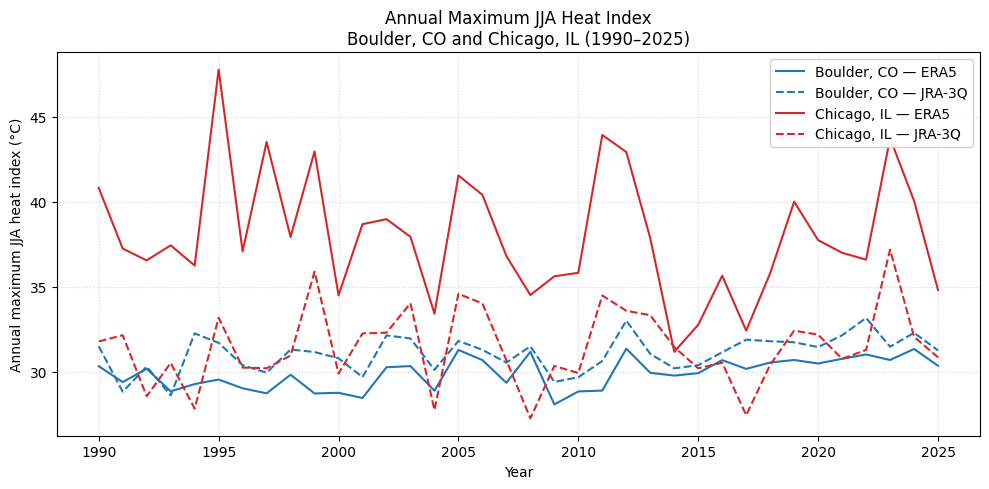

CPU times: user 184 ms, sys: 47.1 ms, total: 231 ms
Wall time: 258 ms


In [21]:
%%time
fig, ax = plt.subplots(figsize=(10, 5))

colors = {"Boulder_CO": "tab:blue", "Chicago_IL": "tab:red"}
ls     = {"ERA5": "-", "JRA-3Q": "--"}

for site in SITES:
    for label, da in results[site].items():
        ax.plot(
            da.year,
            da.values,
            color     = colors[site],
            linestyle = ls[label],
            linewidth = 1.5,
            label     = f"{site.replace('_', ', ')} — {label}",
        )

ax.set_xlabel("Year")
ax.set_ylabel("Annual maximum JJA heat index (°C)")
ax.set_title("Annual Maximum JJA Heat Index\nBoulder, CO and Chicago, IL (1990–2025)")
ax.legend(framealpha=0.9)
ax.grid(linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

- The plot confirms our intuition: Chicago, a more humid place, has a higher JJA maximum heat index w.r.t Boulder
- We see the infamous 1995 Chicago Heat Wave in the plot, but it is not captured by JRA-3Q!
- For both Chicago and Colorado, the predictions from both the ERA5 and JRA-3Q reanalyses seem to broadly agree!

In [22]:
# Close the cluster
cluster.close()

### References

- Romps, D.M., 2024. Heat index extremes increasing several times faster than the air temperature, ERL, 2024 [Environmental Research Letters](https://iopscience.iop.org/article/10.1088/1748-9326/ad3144)
- Lu, Y.-C. and Romps, D.M., 2022. Extending the heat index. *Journal of Applied
  Meteorology and Climatology*, **61**(10), 1367–1383.
  DOI: [10.1175/JAMC-D-22-0021.1](https://doi.org/10.1175/JAMC-D-22-0021.1)
- Lu, Y.-C. and Romps, D.M., 2025. `heatindex`: Tools for Calculating Heat
  Stress, version 0.0.2. <https://heatindex.org>
- Hersbach, H., et al., 2020. The ERA5 global reanalysis. *Quarterly Journal of
  the Royal Meteorological Society*, **146**(730), 1999–2049.
  DOI: [10.1002/qj.3803](https://doi.org/10.1002/qj.3803)
- Kosaka, Y., et al., 2024. The JRA-3Q Reanalysis. *Journal of the
  Meteorological Society of Japan*, **102**, 49–109.
  DOI: [10.2151/jmsj.2024-004](https://doi.org/10.2151/jmsj.2024-004)